# MIOFlow — Spatial Data Preprocessing

## Workflow
1. Load pre-processed Axalotl Spatial Transxriptomics

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
from os import listdir
from os.path import isfile, join
import re

## 1. Load Data

In [2]:
adata = sc.read_h5ad("Axolotl_spatial_processed.h5ad")

/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
# subset data to cell-types of interest in injured samples only
celltypes = ['reaEGC', 'rIPC1', 'rIPC2', 'rIPC3', 'rIPC4', 'IMN', 'nptxEX']
whichin = adata.obs['Annotation'].isin(celltypes)
subdata = adata[whichin]
subdata = subdata[subdata.obs['inj_uninj'] == 'inj']
subdata.obs['Annotation_grouped'] = subdata.obs['Annotation']
subdata.obs['Annotation_grouped'] = ['rIPCs' if np.max(np.equal(['rIPC1', 'rIPC2', 'rIPC3', 'rIPC4'], x)) else x for x in np.array(subdata.obs['Annotation'])]

/tmp/ipykernel_1426380/2771840230.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subdata.obs['Annotation_grouped'] = subdata.obs['Annotation']
/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


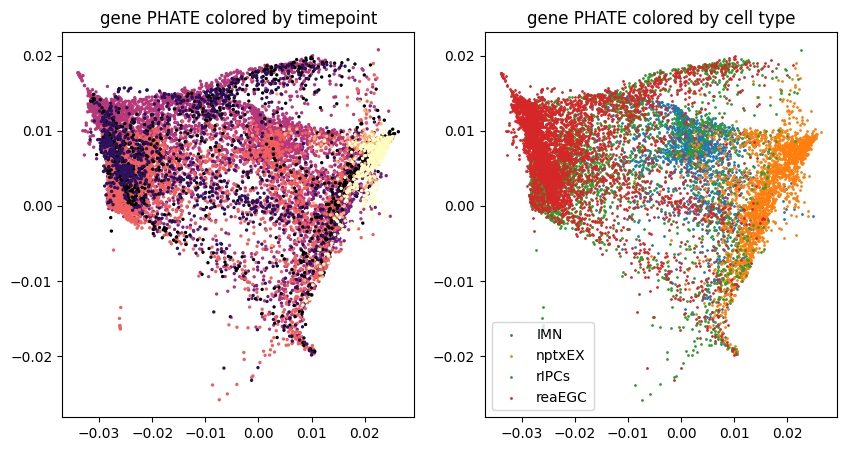

In [4]:
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].scatter(*subdata.obsm['X_phate_gene'].T, s=2, c=np.unique(subdata.obs['dpi'], return_inverse=True)[1], cmap='magma')
axs[0].set_title('gene PHATE colored by timepoint')
for c in np.unique(subdata.obs['Annotation_grouped']):
    axs[1].scatter(*subdata[subdata.obs['Annotation_grouped'] == c].obsm['X_phate_gene'].T, s=1, label=c)
    axs[1].legend()
axs[1].set_title('gene PHATE colored by cell type')
plt.show()

In [5]:
# compute diffusion pseudotime

# set root cells as reaEGC
cands = np.where((subdata.obs['Annotation'] == "reaEGC") * (subdata.obs['dpi'] == 2))[0]
subdata.uns['iroot'] = cands[np.argmax((subdata.obsm['X_phate_gene'][cands] * np.array([-1, 0.2])[None,:]).sum(axis=1))]

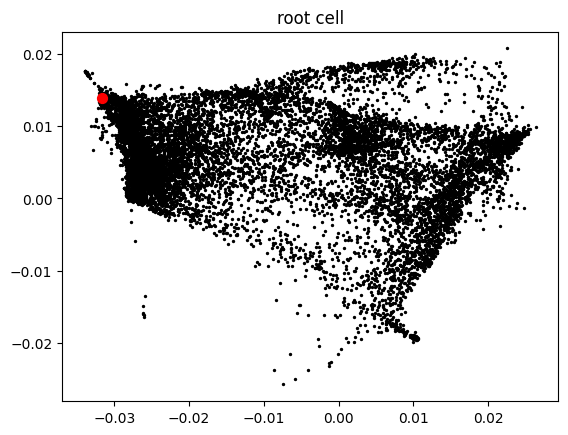

In [6]:
plt.scatter(*subdata.obsm['X_phate_gene'].T, s=2, c='black')
plt.scatter(*subdata.obsm['X_phate_gene'][subdata.uns['iroot']].T, s=50, c='red')
plt.title('root cell')
plt.show()

In [7]:
sc.pp.neighbors(subdata, use_rep='X_pca_harmony')
sc.tl.diffmap(subdata)
sc.tl.dpt(subdata)

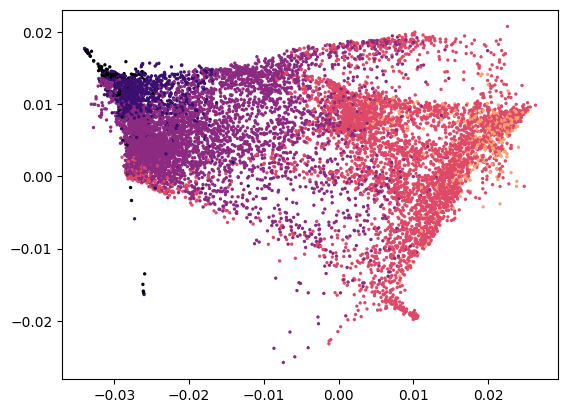

In [8]:
nbins=5
plt.scatter(*subdata.obsm['X_phate_gene'].T, s=2, c=np.digitize(subdata.obs['dpt_pseudotime'], np.linspace(0, 1, nbins+1)), cmap='magma')
plt.show()

In [10]:
subdata.write_h5ad('Axolotl_trajectory_subset.h5ad')